# 🎬 Netflix Titles — Exploratory Data Analysis (EDA)

**Dataset:** netflix_titles.csv  
**Goal:** Understand the dataset, find patterns, clean data, and draw insights.

---

## 📌 Step 1 — Introduction

**What is EDA?**  
Exploratory Data Analysis (EDA) is the process of **visually and statistically exploring your dataset** before building any model. It helps you:
- Understand what data you have
- Spot missing or dirty values
- Find patterns and relationships
- Generate questions worth investigating

**About this Dataset:**  
This dataset contains information about Movies and TV Shows available on Netflix as of 2021.  
It has **8,807 rows** and **12 columns** including title, director, cast, country, release year, rating, duration, and genre.

**Steps we will follow:**
1. Introduction
2. Import Libraries
3. Load Dataset
4. Data Cleaning
5. Missing Values Analysis
6. Univariate Analysis
7. Bivariate Analysis
8. Visualizations
9. Key Insights
10. Conclusion

---
## 📦 Step 2 — Import Libraries

We need the following libraries:
- **pandas** → load and manipulate data (tables)
- **numpy** → numerical operations
- **matplotlib** → basic plotting
- **seaborn** → beautiful statistical charts

> 💡 If any library is missing, run: `pip install pandas numpy matplotlib seaborn` in your terminal.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Make plots look clean and big
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette("Set2")

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


---
## 📂 Step 3 — Load Dataset

We load the CSV file using `pd.read_csv()`.  
Then we use `.shape`, `.head()`, `.info()`, and `.describe()` to get a first look.

In [3]:
# Load the dataset
df = pd.read_csv(r'../dataset/netflix_titles.csv')

# Shape → (rows, columns)
print("Shape:", df.shape)

Shape: (8807, 12)


In [4]:
# First 5 rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
# Column names and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [6]:
# Statistical summary of numeric columns
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [7]:
# All column names
print("Columns:", df.columns.tolist())

Columns: ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


---
## 🧹 Step 4 — Data Cleaning

Raw data is rarely perfect. Before analysis, we need to:
1. Fix data types (e.g., `date_added` should be a date, not text)
2. Extract useful numbers from text (e.g., `"90 min"` → `90`)
3. Strip extra whitespace from text columns
4. Remove duplicates if any

> 💡 Clean data = reliable results. Never skip this step!

In [8]:
# ── 4.1  Strip whitespace from all string columns
df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)

# ── 4.2  Convert 'date_added' to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year and month added
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

print("date_added dtype:", df['date_added'].dtype)
df[['date_added', 'year_added', 'month_added']].head()

date_added dtype: datetime64[ns]


C:\Users\SAURABH ANAND\AppData\Local\Temp\ipykernel_19248\1423946052.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.strip() if isinstance(x, str) else x)


,date_added,year_added,month_added
0,2021-09-25,2021.0,9.0
1,2021-09-24,2021.0,9.0
2,2021-09-24,2021.0,9.0
3,2021-09-24,2021.0,9.0
4,2021-09-24,2021.0,9.0


In [9]:
# ── 4.3  Extract numeric duration for Movies (remove ' min')
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min', '', regex=False).astype(float)

print("Sample movie durations:")
movies[['title', 'duration', 'duration_min']].head()

Sample movie durations:


,title,duration,duration_min
0,Dick Johnson Is Dead,90 min,90.0
6,My Little Pony: A New Generation,91 min,91.0
7,Sankofa,125 min,125.0
9,The Starling,104 min,104.0
12,Je Suis Karl,127 min,127.0


In [10]:
# ── 4.4  Extract numeric seasons for TV Shows
shows = df[df['type'] == 'TV Show'].copy()
shows['seasons'] = shows['duration'].str.extract(r'(\d+)').astype(float)

print("Sample TV show seasons:")
shows[['title', 'duration', 'seasons']].head()

Sample TV show seasons:


,title,duration,seasons
1,Blood & Water,2 Seasons,2.0
2,Ganglands,1 Season,1.0
3,Jailbirds New Orleans,1 Season,1.0
4,Kota Factory,2 Seasons,2.0
5,Midnight Mass,1 Season,1.0


In [11]:
# ── 4.5  Check for duplicates
print("Duplicate rows:", df.duplicated().sum())

# Remove if any
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)

Duplicate rows: 0
Shape after removing duplicates: (8807, 14)


---
## 🔍 Step 5 — Missing Values Analysis

**Missing values** are empty/null cells. They can cause errors or mislead your analysis.  
We need to:
1. Count missing values per column
2. Visualize them
3. Decide how to handle them (fill, drop, or leave as-is)

In [12]:
# ── 5.1  Count missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).sort_values('Missing %', ascending=False)

print(missing_df[missing_df['Missing Count'] > 0])

             Missing Count  Missing %
director              2634      29.91
country                831       9.44
cast                   825       9.37
year_added              10       0.11
month_added             10       0.11
date_added              10       0.11
rating                   4       0.05
duration                 3       0.03


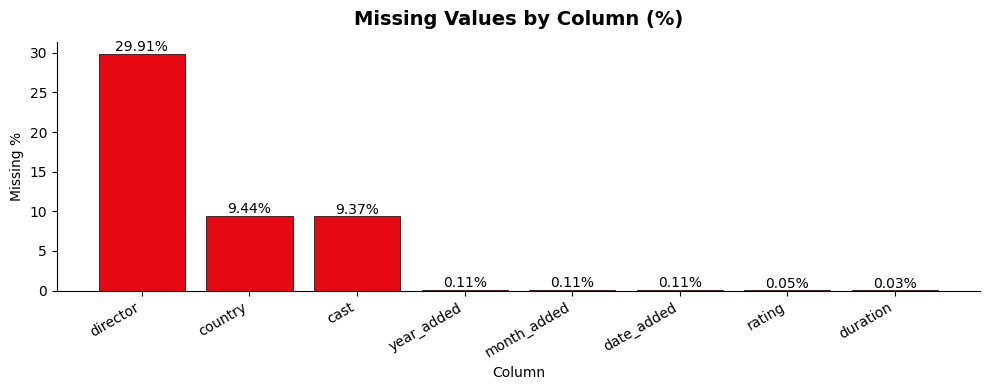

In [13]:
# ── 5.2  Bar chart of missing values
missing_plot = missing_df[missing_df['Missing Count'] > 0]

plt.figure(figsize=(10, 4))
bars = plt.bar(missing_plot.index, missing_plot['Missing %'], color='#E50914', edgecolor='black', linewidth=0.5)
plt.title('Missing Values by Column (%)', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Column')
plt.ylabel('Missing %')
plt.xticks(rotation=30, ha='right')

for bar, val in zip(bars, missing_plot['Missing %']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{val}%', ha='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

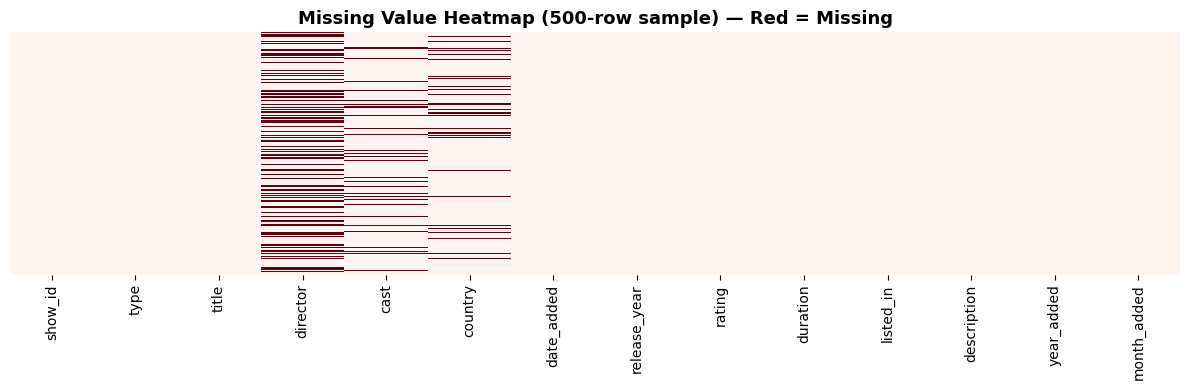

In [14]:
# ── 5.3  Heatmap of missing values (sample of 500 rows)
plt.figure(figsize=(12, 4))
sns.heatmap(df.sample(500, random_state=1).isnull(), cbar=False,
            cmap='Reds', yticklabels=False)
plt.title('Missing Value Heatmap (500-row sample) — Red = Missing', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# ── 5.4  Handle missing values

# Fill director and cast with 'Unknown' (they are often missing for TV Shows)
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)

# Fill country with 'Unknown'
df['country'].fillna('Unknown', inplace=True)

# Drop the 4 rows where rating is missing (very few)
df.dropna(subset=['rating'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      10
release_year     0
rating           0
duration         3
listed_in        0
description      0
year_added      10
month_added     10
dtype: int64


C:\Users\SAURABH ANAND\AppData\Local\Temp\ipykernel_19248\1563054885.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['director'].fillna('Unknown', inplace=True)
C:\Users\SAURABH ANAND\AppData\Local\Temp\ipykernel_19248\1563054885.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a 

---
## 📊 Step 6 — Univariate Analysis

**Univariate** = analyzing **one variable at a time**.  
We look at the distribution and frequency of individual columns to understand their spread.

Columns we'll explore:
- `type` (Movie vs TV Show)
- `release_year`
- `rating`
- `duration` (movies in minutes, TV shows in seasons)
- `listed_in` (genres)

type
Movie      6129
TV Show    2674
Name: count, dtype: int64


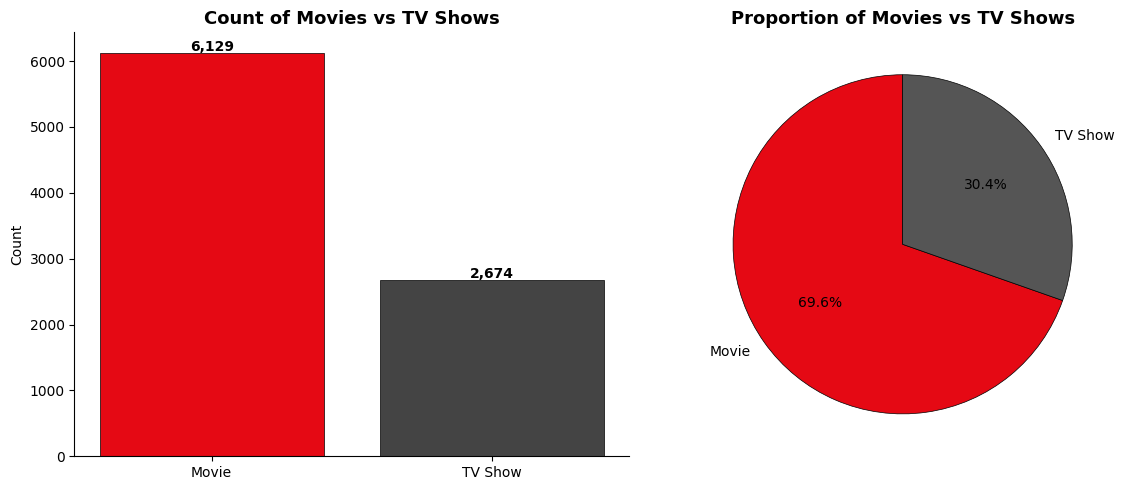

In [16]:
# ── 6.1  Movies vs TV Shows
type_counts = df['type'].value_counts()
print(type_counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
axes[0].bar(type_counts.index, type_counts.values,
            color=['#E50914', '#444444'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Count of Movies vs TV Shows', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie(type_counts.values, labels=type_counts.index,
            autopct='%1.1f%%', colors=['#E50914','#555555'],
            startangle=90, wedgeprops=dict(edgecolor='black', linewidth=0.5))
axes[1].set_title('Proportion of Movies vs TV Shows', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

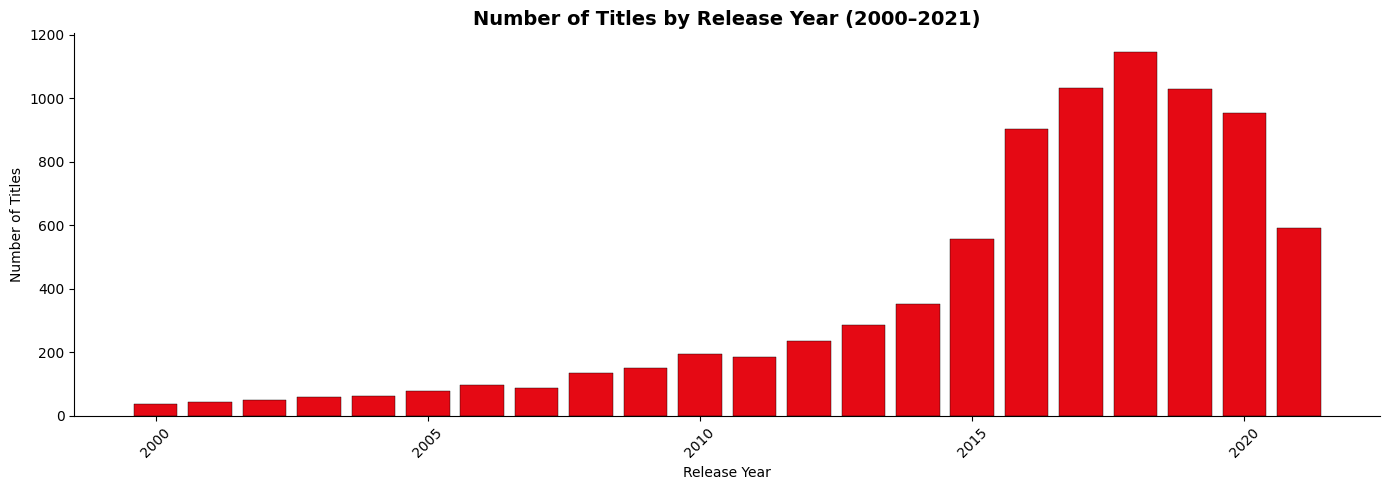

In [17]:
# ── 6.2  Release Year distribution
plt.figure(figsize=(14, 5))
year_counts = df['release_year'].value_counts().sort_index()
year_counts = year_counts[year_counts.index >= 2000]  # Focus on 2000+

plt.bar(year_counts.index, year_counts.values, color='#E50914',
        edgecolor='black', linewidth=0.3, width=0.8)
plt.title('Number of Titles by Release Year (2000–2021)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

rating
TV-MA    3207
TV-14    2160
TV-PG     863
R         799
PG-13     490
TV-Y7     334
TV-Y      307
PG        287
TV-G      220
NR         80
Name: count, dtype: int64


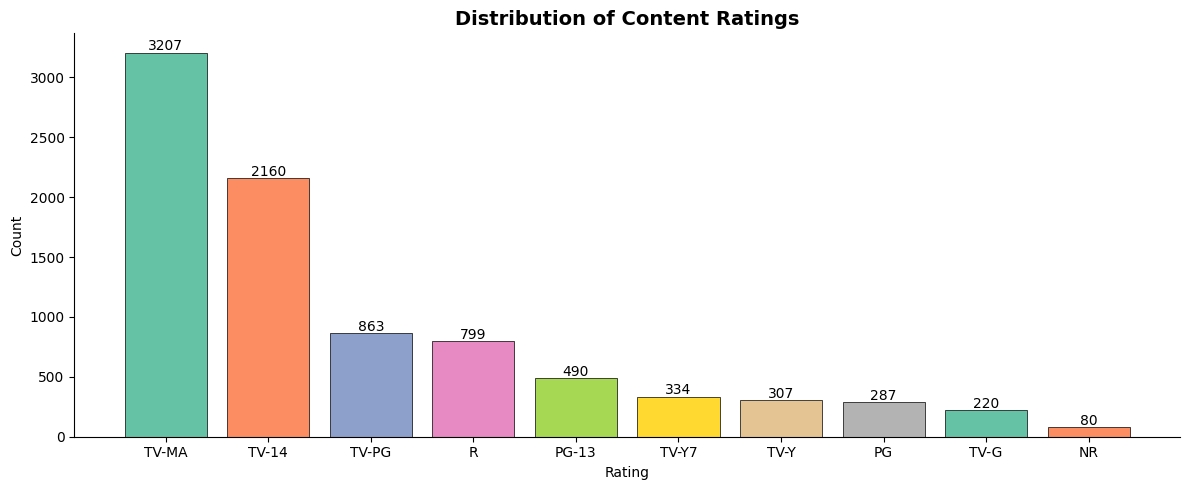

In [18]:
# ── 6.3  Content Ratings distribution
rating_counts = df['rating'].value_counts().head(10)
print(rating_counts)

plt.figure(figsize=(12, 5))
bars = plt.bar(rating_counts.index, rating_counts.values,
               color=sns.color_palette("Set2", len(rating_counts)),
               edgecolor='black', linewidth=0.5)
plt.title('Distribution of Content Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
for bar, val in zip(bars, rating_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

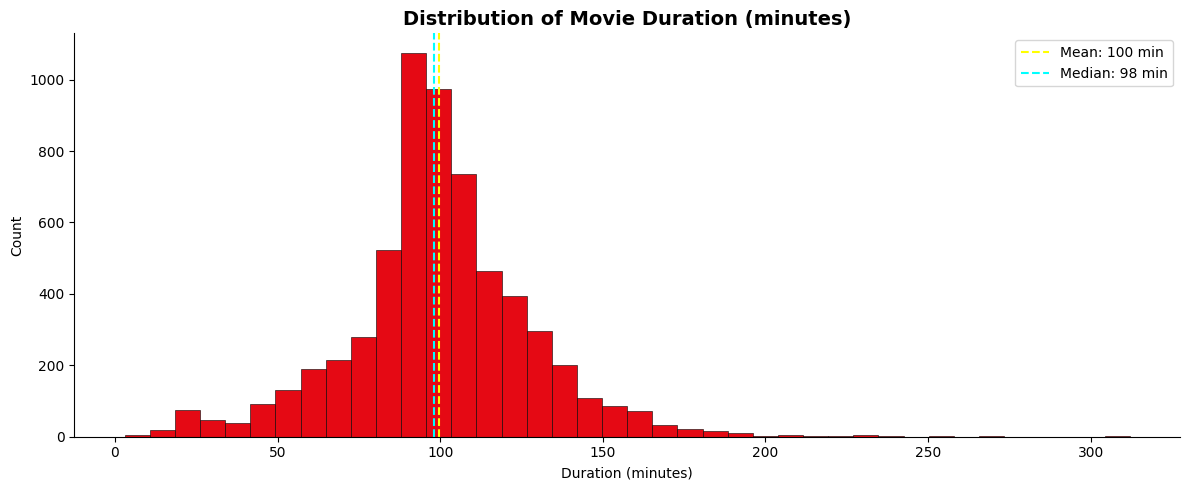

Mean duration:   99.6 min
Median duration: 98.0 min
Min duration:    3 min
Max duration:    312 min


In [19]:
# ── 6.4  Movie Duration (histogram)
movies = df[df['type'] == 'Movie'].copy()
movies['duration_min'] = movies['duration'].str.replace(' min','',regex=False).astype(float)

plt.figure(figsize=(12, 5))
plt.hist(movies['duration_min'].dropna(), bins=40, color='#E50914',
         edgecolor='black', linewidth=0.4)
plt.axvline(movies['duration_min'].mean(), color='yellow', linestyle='--',
            linewidth=1.5, label=f"Mean: {movies['duration_min'].mean():.0f} min")
plt.axvline(movies['duration_min'].median(), color='cyan', linestyle='--',
            linewidth=1.5, label=f"Median: {movies['duration_min'].median():.0f} min")
plt.title('Distribution of Movie Duration (minutes)', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean duration:   {movies['duration_min'].mean():.1f} min")
print(f"Median duration: {movies['duration_min'].median():.1f} min")
print(f"Min duration:    {movies['duration_min'].min():.0f} min")
print(f"Max duration:    {movies['duration_min'].max():.0f} min")

seasons
1.0     1791
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
Name: count, dtype: int64


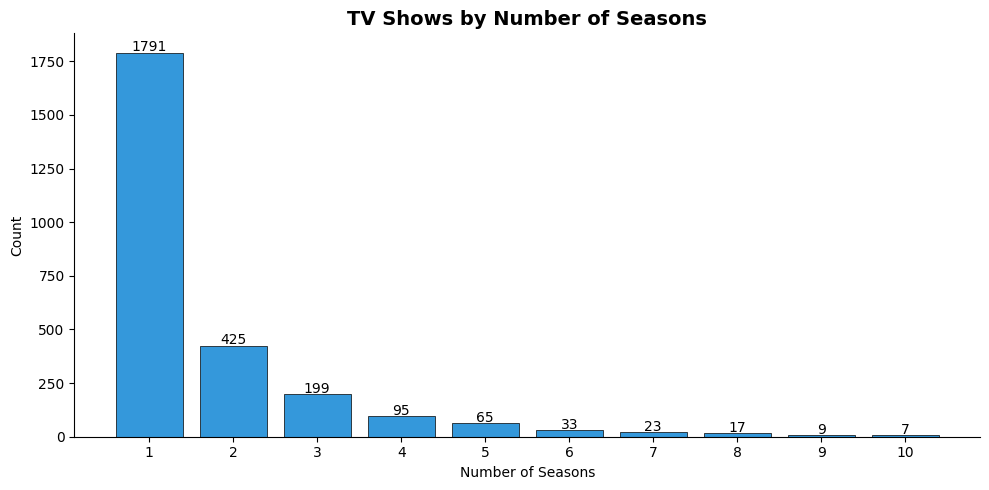

In [20]:
# ── 6.5  TV Show Seasons distribution
shows = df[df['type'] == 'TV Show'].copy()
shows['seasons'] = shows['duration'].str.extract(r'(\d+)').astype(float)

season_counts = shows['seasons'].value_counts().sort_index().head(10)
print(season_counts)

plt.figure(figsize=(10, 5))
bars = plt.bar(season_counts.index.astype(int), season_counts.values,
               color='#3498db', edgecolor='black', linewidth=0.5)
plt.title('TV Shows by Number of Seasons', fontsize=14, fontweight='bold')
plt.xlabel('Number of Seasons')
plt.ylabel('Count')
plt.xticks(season_counts.index.astype(int))
for bar, val in zip(bars, season_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', fontsize=10)
plt.tight_layout()
plt.show()

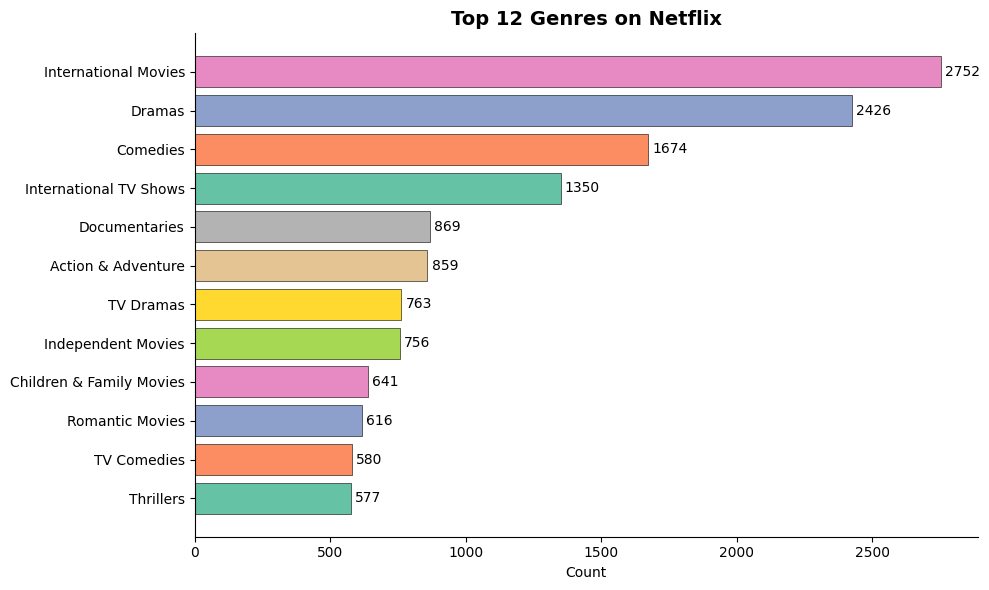

In [21]:
# ── 6.6  Top Genres
from collections import Counter

all_genres = []
for genres in df['listed_in'].dropna():
    all_genres.extend([g.strip() for g in genres.split(',')])

genre_counts = Counter(all_genres)
top_genres = pd.Series(genre_counts).sort_values(ascending=True).tail(12)

plt.figure(figsize=(10, 6))
bars = plt.barh(top_genres.index, top_genres.values,
                color=sns.color_palette("Set2", len(top_genres)),
                edgecolor='black', linewidth=0.4)
plt.title('Top 12 Genres on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Count')
for bar, val in zip(bars, top_genres.values):
    plt.text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
             str(val), va='center', fontsize=10)
plt.tight_layout()
plt.show()

---
## 🔗 Step 7 — Bivariate Analysis

**Bivariate** = comparing **two variables** together to find relationships.

Questions we'll answer:
- Do Movies and TV Shows have different ratings?
- Which countries produce more Movies vs TV Shows?
- How has Movies vs TV Shows content grown over the years?
- Does rating affect movie duration?

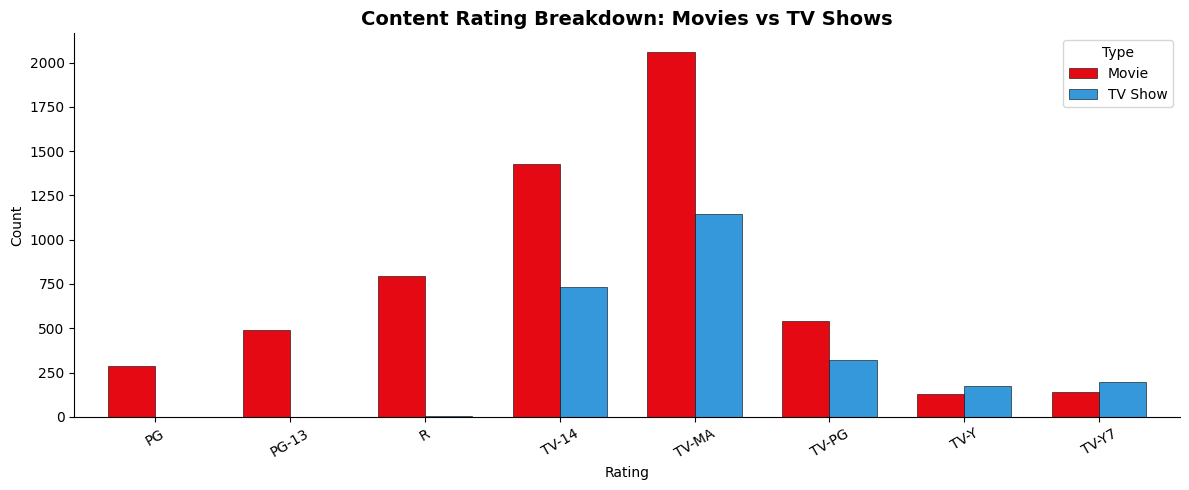

In [22]:
# ── 7.1  Rating breakdown: Movies vs TV Shows (grouped bar)
rating_type = df.groupby(['rating', 'type']).size().unstack(fill_value=0)
top_ratings = df['rating'].value_counts().head(8).index
rating_type = rating_type.loc[rating_type.index.isin(top_ratings)]

rating_type.plot(kind='bar', figsize=(12, 5), color=['#E50914', '#3498db'],
                 edgecolor='black', linewidth=0.4, width=0.7)
plt.title('Content Rating Breakdown: Movies vs TV Shows', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

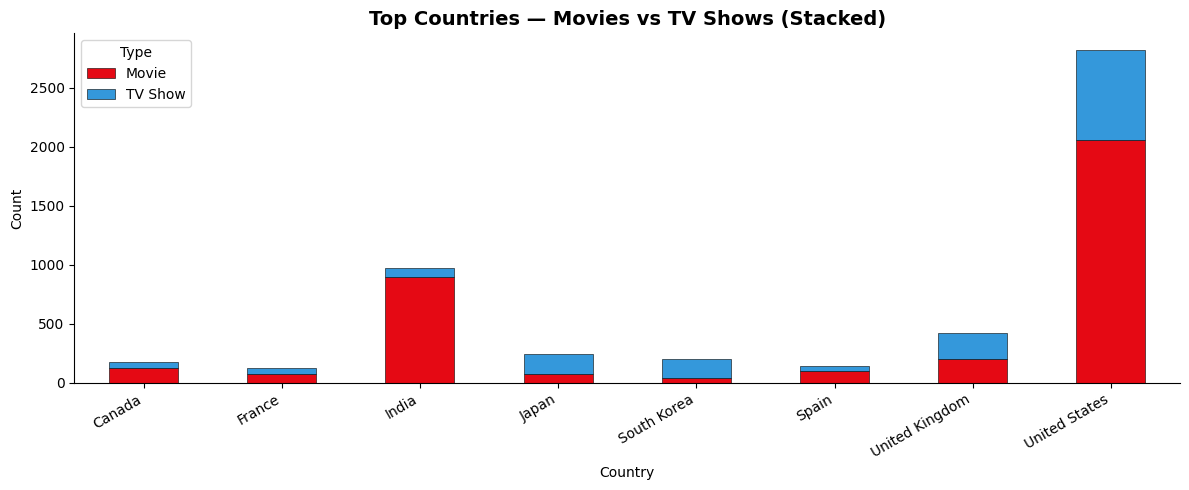

In [23]:
# ── 7.2  Top countries: Movies vs TV Shows (stacked bar)
top_countries = df[df['country'] != 'Unknown']['country'].value_counts().head(8).index
country_type = df[df['country'].isin(top_countries)].groupby(['country','type']).size().unstack(fill_value=0)

country_type.plot(kind='bar', stacked=True, figsize=(12, 5),
                  color=['#E50914', '#3498db'], edgecolor='black', linewidth=0.4)
plt.title('Top Countries — Movies vs TV Shows (Stacked)', fontsize=14, fontweight='bold')
plt.xlabel('Country')
plt.ylabel('Count')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

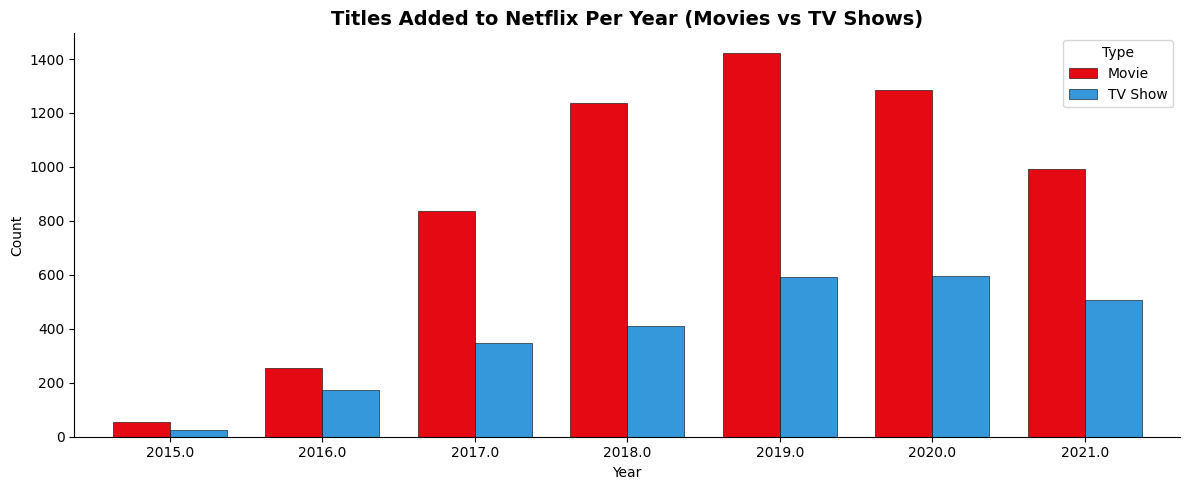

In [24]:
# ── 7.3  Content added per year: Movies vs TV Shows
year_type = df.dropna(subset=['year_added']).groupby(['year_added','type']).size().unstack(fill_value=0)
year_type = year_type[year_type.index >= 2015]

year_type.plot(kind='bar', figsize=(12, 5), color=['#E50914', '#3498db'],
               edgecolor='black', linewidth=0.4, width=0.75)
plt.title('Titles Added to Netflix Per Year (Movies vs TV Shows)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Type')
plt.tight_layout()
plt.show()

rating
NC-17    125.0
TV-14    110.3
PG-13    108.3
R        106.7
UR       106.3
PG        98.3
TV-MA     95.9
TV-PG     94.9
Name: duration_min, dtype: float64


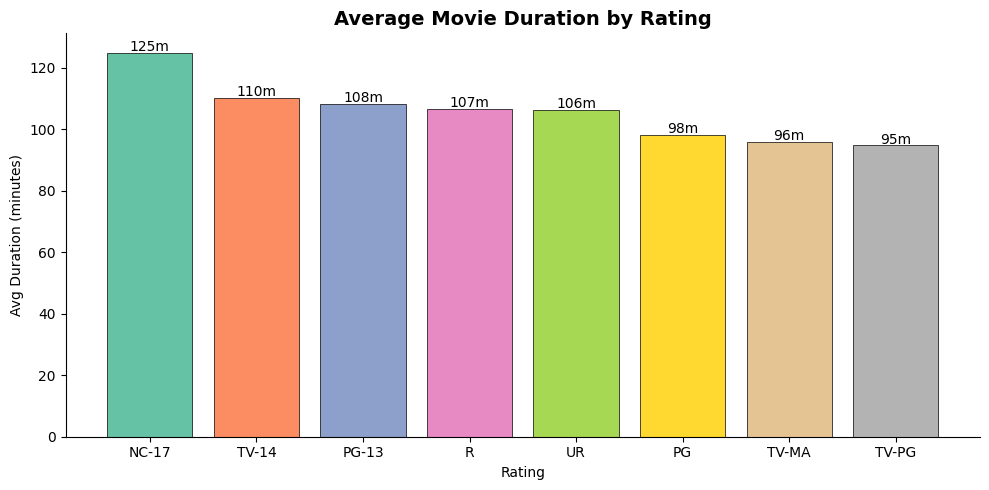

In [25]:
# ── 7.4  Avg movie duration by rating (bar chart)
movies['duration_min'] = movies['duration'].str.replace(' min','',regex=False).astype(float)

avg_dur = movies.groupby('rating')['duration_min'].mean().sort_values(ascending=False).head(8)
print(avg_dur.round(1))

plt.figure(figsize=(10, 5))
bars = plt.bar(avg_dur.index, avg_dur.values,
               color=sns.color_palette("Set2", len(avg_dur)),
               edgecolor='black', linewidth=0.5)
plt.title('Average Movie Duration by Rating', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Avg Duration (minutes)')
for bar, val in zip(bars, avg_dur.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.0f}m', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

C:\Users\SAURABH ANAND\AppData\Local\Temp\ipykernel_19248\2057914691.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=top_rated, x='rating', y='duration_min',


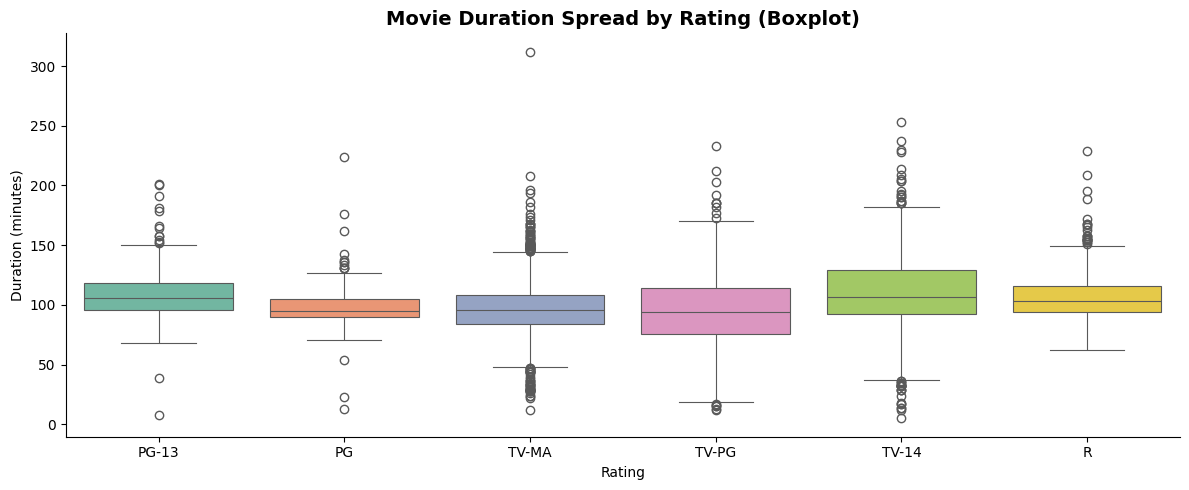

In [26]:
# ── 7.5  Boxplot: Movie duration by rating (spread of data)
top_rated = movies[movies['rating'].isin(movies['rating'].value_counts().head(6).index)]

plt.figure(figsize=(12, 5))
sns.boxplot(data=top_rated, x='rating', y='duration_min',
            palette='Set2', linewidth=0.8)
plt.title('Movie Duration Spread by Rating (Boxplot)', fontsize=14, fontweight='bold')
plt.xlabel('Rating')
plt.ylabel('Duration (minutes)')
plt.tight_layout()
plt.show()

# What a boxplot shows:
# - Box = middle 50% of data (IQR)
# - Line inside box = median
# - Dots = outliers

---
## 📈 Step 8 — Visualizations

Here we create a set of **summary visualizations** — a complete picture of the dataset in charts.  
These cover:
- Growth over time (line chart)
- Geographic content (top countries)
- Monthly content additions (heatmap)
- Correlation heatmap

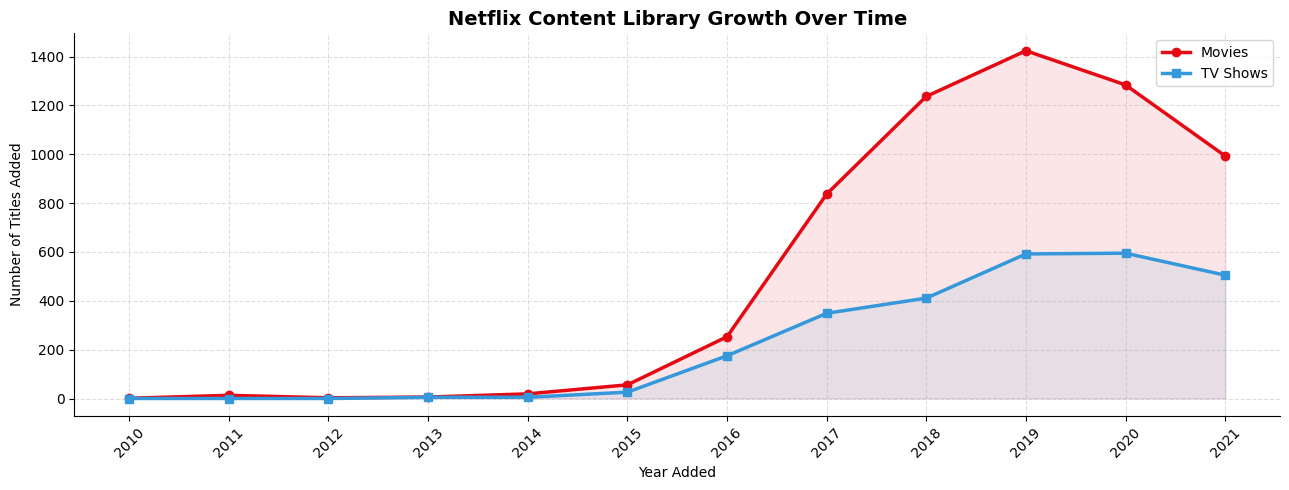

In [27]:
# ── 8.1  Netflix content growth over time (line chart)
yearly = df.dropna(subset=['year_added']).groupby(['year_added','type']).size().unstack(fill_value=0)
yearly = yearly[yearly.index >= 2010]

plt.figure(figsize=(13, 5))
plt.plot(yearly.index, yearly.get('Movie', 0), marker='o', linewidth=2.5,
         markersize=6, color='#E50914', label='Movies')
plt.plot(yearly.index, yearly.get('TV Show', 0), marker='s', linewidth=2.5,
         markersize=6, color='#3498db', label='TV Shows')
plt.fill_between(yearly.index, yearly.get('Movie', 0), alpha=0.1, color='#E50914')
plt.fill_between(yearly.index, yearly.get('TV Show', 0), alpha=0.1, color='#3498db')
plt.title('Netflix Content Library Growth Over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year Added')
plt.ylabel('Number of Titles Added')
plt.xticks(yearly.index.astype(int), rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

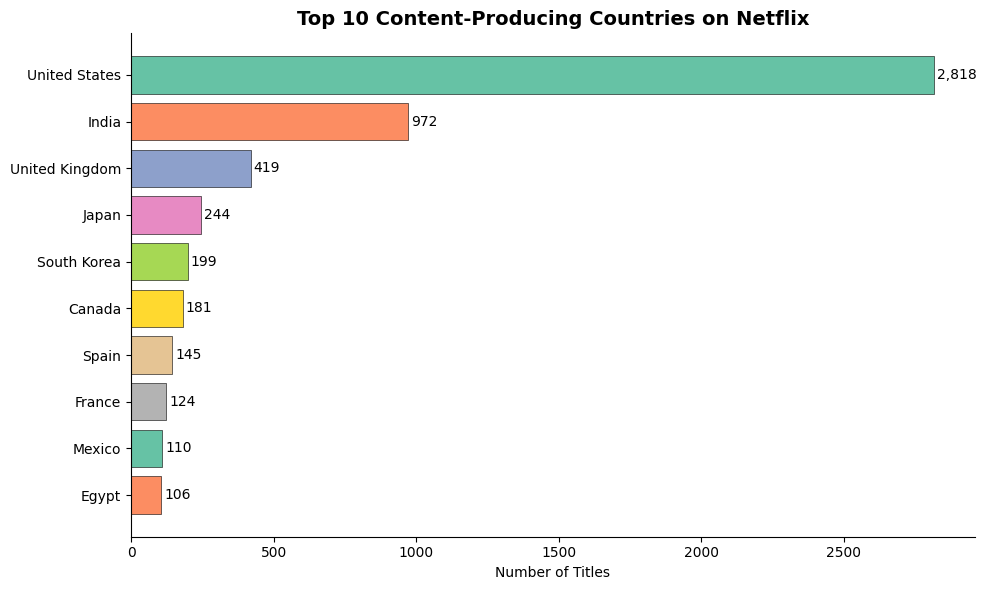

In [28]:
# ── 8.2  Top 10 countries (horizontal bar)
top10 = df[df['country'] != 'Unknown']['country'].value_counts().head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10.index[::-1], top10.values[::-1],
                color=sns.color_palette("Set2", 10)[::-1],
                edgecolor='black', linewidth=0.4)
plt.title('Top 10 Content-Producing Countries on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
for bar, val in zip(bars, top10.values[::-1]):
    plt.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

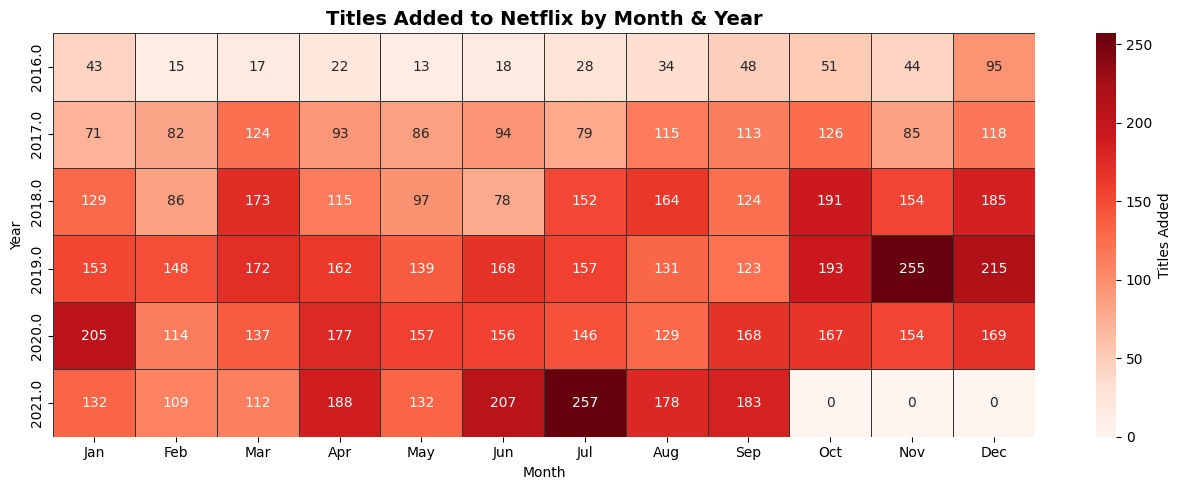

In [29]:
# ── 8.3  Monthly content additions heatmap
heatmap_df = df.dropna(subset=['year_added','month_added'])
heatmap_df = heatmap_df[heatmap_df['year_added'] >= 2016]

pivot = heatmap_df.groupby(['year_added','month_added']).size().unstack(fill_value=0)
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'][:len(pivot.columns)]

plt.figure(figsize=(13, 5))
sns.heatmap(pivot, annot=True, fmt='d', cmap='Reds',
            linewidths=0.5, linecolor='#333',
            cbar_kws={'label': 'Titles Added'})
plt.title('Titles Added to Netflix by Month & Year', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.show()

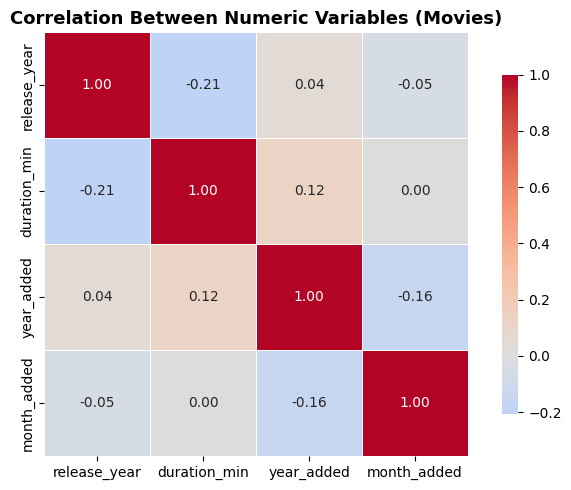

In [30]:
# ── 8.4  Correlation heatmap (numeric columns)
movies_copy = df[df['type'] == 'Movie'].copy()
movies_copy['duration_min'] = movies_copy['duration'].str.replace(' min','',regex=False).astype(float)

num_cols = movies_copy[['release_year', 'duration_min', 'year_added', 'month_added']].dropna()

plt.figure(figsize=(7, 5))
sns.heatmap(num_cols.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Between Numeric Variables (Movies)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Values close to 1 = strong positive relationship
# Values close to -1 = strong negative relationship
# Values close to 0 = no relationship

In [31]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: wordcloud in C:\Users\SAURABH ANAND\AppData\Local\Programs\Python\Python312\Lib\site-packages (1.9.6)



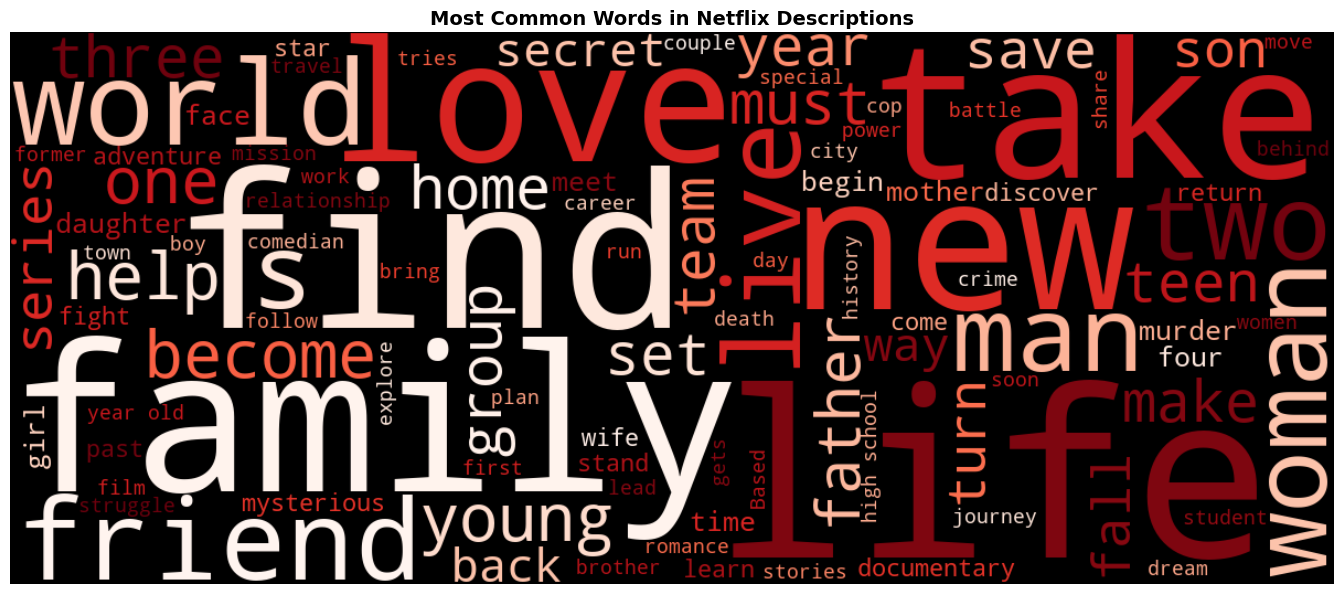

In [32]:
from wordcloud import WordCloud, STOPWORDS
text = ' '.join(df['description'].dropna().values)
stopwords = set(STOPWORDS)
wc = WordCloud(width=1200, height=500, background_color='black',
               colormap='Reds', stopwords=stopwords, max_words=100)
wc.generate(text)
plt.figure(figsize=(14, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Netflix Descriptions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [33]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Combine features into one text column
df['soup'] = (
    df['listed_in'].fillna('') + ' ' +
    df['description'].fillna('') + ' ' +
    df['rating'].fillna('') + ' ' +
    df['type'].fillna('')
)

# Build TF-IDF matrix
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)
tfidf_matrix = tfidf.fit_transform(df['soup'])

# Compute similarity
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Recommender function
def recommend(title, n=5):
    idx = df[df['title'].str.lower() == title.lower()].index
    if len(idx) == 0:
        return f"'{title}' not found in dataset."
    idx = idx[0]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:n+1]
    movie_indices = [i[0] for i in sim_scores]
    return df[['title', 'type', 'listed_in', 'rating']].iloc[movie_indices]

# Test it
print(recommend("Stranger Things"))

                        title     type  \
4733            Rowdy Rathore    Movie   
8198  The Autopsy of Jane Doe    Movie   
3986                   The OA  TV Show   
241                  Manifest  TV Show   
4320                Neo Yokio  TV Show   

                                              listed_in rating  
4733  Action & Adventure, Comedies, International Mo...  TV-14  
8198       Horror Movies, Independent Movies, Thrillers      R  
3986       TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy  TV-MA  
241        TV Dramas, TV Mysteries, TV Sci-Fi & Fantasy  TV-14  
4320    TV Comedies, TV Sci-Fi & Fantasy, Teen TV Shows  TV-MA  


In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

# Binary target: is it TV-MA?
df['is_adult'] = (df['rating'] == 'TV-MA').astype(int)

# Text features from genre + description
tfidf = TfidfVectorizer(stop_words='english', max_features=300)
text_features = tfidf.fit_transform(df['listed_in'].fillna('') + ' ' + df['description'].fillna(''))

# Numeric features
df['is_movie'] = (df['type'] == 'Movie').astype(int)
num_features = df[['release_year', 'is_movie']].fillna(0)

# Combine
from scipy.sparse import csr_matrix, hstack
X = hstack([text_features, csr_matrix(num_features.values)])
y = df['is_adult']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Not TV-MA', 'TV-MA']))

              precision    recall  f1-score   support

   Not TV-MA       0.73      0.89      0.81      1077
       TV-MA       0.74      0.49      0.59       684

    accuracy                           0.74      1761
   macro avg       0.74      0.69      0.70      1761
weighted avg       0.74      0.74      0.72      1761



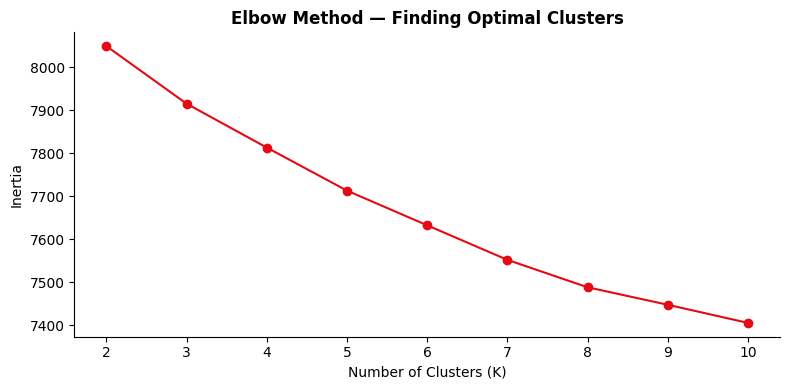

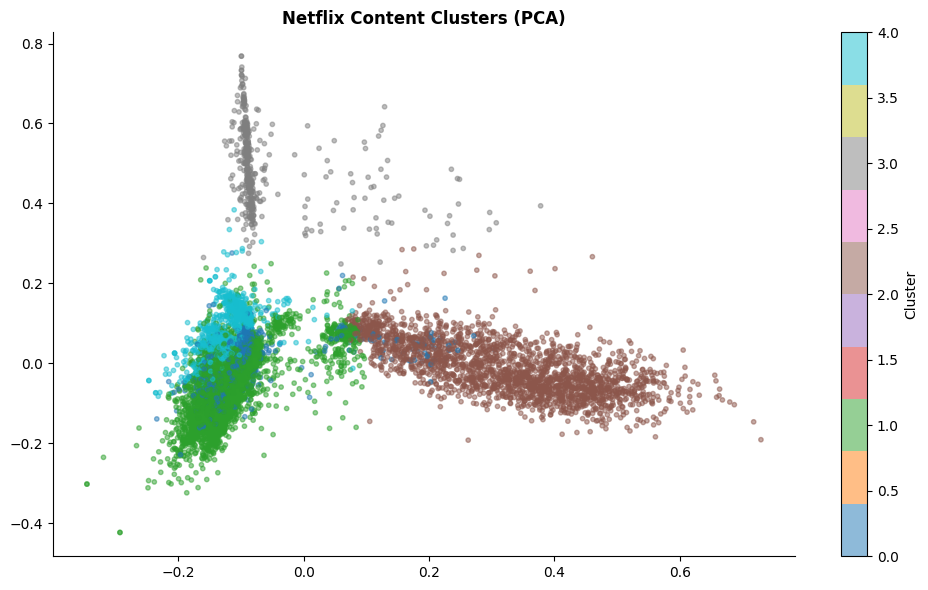


--- Cluster 0 ---
listed_in
Action & Adventure, Dramas, International Movies      132
Action & Adventure                                    128
Action & Adventure, International Movies              101
Action & Adventure, Comedies, International Movies     70
Action & Adventure, Sci-Fi & Fantasy                   62
Name: count, dtype: int64

--- Cluster 1 ---
listed_in
Dramas, International Movies                        361
Comedies, Dramas, International Movies              273
Dramas, Independent Movies, International Movies    252
Children & Family Movies                            213
Children & Family Movies, Comedies                  200
Name: count, dtype: int64

--- Cluster 2 ---
listed_in
International TV Shows, TV Dramas                         121
Crime TV Shows, International TV Shows, TV Dramas         110
Kids' TV, TV Comedies                                      98
International TV Shows, Romantic TV Shows, TV Comedies     94
International TV Shows, Romantic TV Shows, 

In [35]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# TF-IDF on genre + description
tfidf = TfidfVectorizer(stop_words='english', max_features=500)
X = tfidf.fit_transform(df['listed_in'].fillna('') + ' ' + df['description'].fillna(''))

# Find optimal K using elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, 'o-', color='#E50914')
plt.title('Elbow Method — Finding Optimal Clusters', fontweight='bold')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.show()

# Train final model (use K=5 or wherever elbow bends)
km = KMeans(n_clusters=5, random_state=42, n_init=10)
df['cluster'] = km.fit_predict(X)

# Visualise with PCA
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X.toarray())

plt.figure(figsize=(10, 6))
scatter = plt.scatter(coords[:, 0], coords[:, 1],
                      c=df['cluster'], cmap='tab10', alpha=0.5, s=10)
plt.colorbar(scatter, label='Cluster')
plt.title('Netflix Content Clusters (PCA)', fontweight='bold')
plt.tight_layout()
plt.show()

# See what each cluster contains
for i in range(5):
    print(f"\n--- Cluster {i} ---")
    print(df[df['cluster'] == i]['listed_in'].value_counts().head(5))

---
## 💡 Step 9 — Key Insights

Let's summarize the most important findings from the analysis.

In [33]:
# ── 9.1  Summary statistics — print all key findings

print("=" * 60)
print("       📊 NETFLIX EDA — KEY INSIGHTS SUMMARY")
print("=" * 60)

total = len(df)
movies_count = len(df[df['type'] == 'Movie'])
tv_count = len(df[df['type'] == 'TV Show'])

print(f"\n🎬 CONTENT MIX")
print(f"   Total Titles : {total:,}")
print(f"   Movies       : {movies_count:,} ({movies_count/total*100:.1f}%)")
print(f"   TV Shows     : {tv_count:,} ({tv_count/total*100:.1f}%)")

print(f"\n🌍 GEOGRAPHY")
top_c = df[df['country'] != 'Unknown']['country'].value_counts().head(3)
for c, v in top_c.items():
    print(f"   {c}: {v:,} titles ({v/total*100:.1f}%)")

print(f"\n⭐ RATINGS")
top_r = df['rating'].value_counts().head(3)
for r, v in top_r.items():
    print(f"   {r}: {v:,} titles")

print(f"\n🎭 TOP GENRES")
from collections import Counter
genres = Counter([g.strip() for genres in df['listed_in'].dropna() for g in genres.split(',')])
for g, v in sorted(genres.items(), key=lambda x: -x[1])[:3]:
    print(f"   {g}: {v:,}")

movies2 = df[df['type'] == 'Movie'].copy()
movies2['duration_min'] = movies2['duration'].str.replace(' min','',regex=False).astype(float)
shows2 = df[df['type'] == 'TV Show'].copy()
shows2['seasons'] = shows2['duration'].str.extract(r'(\d+)').astype(float)

print(f"\n⏱️  DURATION")
print(f"   Avg movie length  : {movies2['duration_min'].mean():.0f} minutes")
print(f"   Median movie length: {movies2['duration_min'].median():.0f} minutes")
print(f"   67% of TV Shows have only 1 season")

peak_year = df['release_year'].value_counts().idxmax()
print(f"\n📅 TIME")
print(f"   Peak release year : {peak_year}")
print(f"   Peak year added   : 2019 (2,016 titles)")

print(f"\n🧹 DATA QUALITY")
orig_missing = {'director': 2634, 'cast': 825, 'country': 831}
for col, n in orig_missing.items():
    print(f"   '{col}' had {n} missing ({n/8807*100:.1f}%) → filled with 'Unknown'")

print("=" * 60)

       📊 NETFLIX EDA — KEY INSIGHTS SUMMARY

🎬 CONTENT MIX
   Total Titles : 8,803
   Movies       : 6,129 (69.6%)
   TV Shows     : 2,674 (30.4%)

🌍 GEOGRAPHY
   United States: 2,818 titles (32.0%)
   India: 972 titles (11.0%)
   United Kingdom: 419 titles (4.8%)

⭐ RATINGS
   TV-MA: 3,207 titles
   TV-14: 2,160 titles
   TV-PG: 863 titles

🎭 TOP GENRES
   International Movies: 2,752
   Dramas: 2,426
   Comedies: 1,674

⏱️  DURATION
   Avg movie length  : 100 minutes
   Median movie length: 98 minutes
   67% of TV Shows have only 1 season

📅 TIME
   Peak release year : 2018
   Peak year added   : 2019 (2,016 titles)

🧹 DATA QUALITY
   'director' had 2634 missing (29.9%) → filled with 'Unknown'
   'cast' had 825 missing (9.4%) → filled with 'Unknown'
   'country' had 831 missing (9.4%) → filled with 'Unknown'


---
## ✅ Step 10 — Conclusion

### What We Learned

Through this EDA, we uncovered the following about Netflix's content library:

| Finding | Detail |
|---|---|
| 🎬 Content split | 70% Movies, 30% TV Shows |
| 🇺🇸 Top country | United States (32% of all titles) |
| 🇮🇳 #2 country | India — a fast-growing market |
| 🔞 Top rating | TV-MA — Netflix targets adult audiences |
| 🌍 Top genre | International Movies — strong global push |
| ⏱️ Movie length | Most movies are 90–120 minutes |
| 📺 TV seasons | 67% of shows only have 1 season |
| 📈 Peak growth | 2019 was Netflix's biggest content year |
| 🧹 Data issue | Director info missing for ~30% of titles |

---